<a href="https://colab.research.google.com/github/o-allanribeiro/Portfolio-CAPM/blob/main/Treinando_carteira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portfolio-CAPM: risco, retorno e precificação com Python

Este notebook percorre, de ponta a ponta, as ferramentas básicas de finanças quantitativas aplicadas a
uma carteira de ações brasileiras:

1. dados de mercado (Yahoo Finance) e taxa livre de risco (Selic, Banco Central);
2. retornos, risco e correlação;
3. uma carteira 30/40/30 (PETR4, VALE3, BBDC4): retorno, volatilidade e índice de Sharpe;
4. retorno esperado e variância por cenários (exercício didático);
5. **CAPM**: beta contra o Ibovespa, linha do mercado de títulos (SML) e alfa de Jensen;
6. **fronteira eficiente** de Markowitz;
7. **Black-Scholes**: preço de opção europeia, paridade put-call e verificação por Monte Carlo.

> **Aviso.** Material educacional. Os resultados são **históricos e dentro da amostra**: retorno passado não
> garante retorno futuro, e nada aqui é recomendação de investimento.

**Como executar:** `pip install -r requirements.txt` e abra o notebook (ou use o botão do Colab acima).
A janela de dados é fixa (2019-01-01 a 2025-12-31) para que os resultados sejam reproduzíveis.

In [1]:
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

TICKERS = ["PETR4.SA", "VALE3.SA", "BBDC4.SA"]
MARKET = "^BVSP"          # Ibovespa como proxy da carteira de mercado
START, END = "2019-01-01", "2025-12-31"
TRADING_DAYS = 252
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

print("pandas", pd.__version__, "| numpy", np.__version__, "| yfinance", yf.__version__)

pandas 2.3.3 | numpy 2.4.1 | yfinance 1.5.2


## 1. Dados

Preços de fechamento **ajustados** por dividendos e desdobramentos (Yahoo Finance), alinhados em datas
em que todos os ativos negociaram. A taxa livre de risco vem da série SGS 1178 do Banco Central (Selic
anualizada, base 252 dias úteis).

In [2]:
raw = yf.download(TICKERS + [MARKET], start=START, end=END, auto_adjust=True, progress=False)["Close"]
prices = raw[TICKERS + [MARKET]].dropna()

print(f"{prices.shape[0]} pregões, de {prices.index.min().date()} a {prices.index.max().date()}")
assert prices.shape[0] > 1500, "poucos dados baixados; verifique a conexão"
assert (prices > 0).all().all()
prices.tail()

1742 pregões, de 2019-01-02 a 2025-12-30


Ticker,PETR4.SA,VALE3.SA,BBDC4.SA,^BVSP
Date,,,,
2025-12-22,28.346941,70.929672,17.079201,158142.0
2025-12-23,28.499384,70.910225,17.238380,160456.0
2025-12-26,28.593410,71.124222,17.229015,160897.0
2025-12-29,28.894295,70.151512,17.313288,160490.0
2025-12-30,28.978918,69.995880,17.395191,161125.0


In [3]:
def selic_diaria(start, end):
    """Taxa Selic diaria (decimal) a partir da SGS 1178 (% a.a., base 252)."""
    url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.1178/dados"
    params = {"formato": "json", "dataInicial": pd.Timestamp(start).strftime("%d/%m/%Y"),
              "dataFinal": pd.Timestamp(end).strftime("%d/%m/%Y")}
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    s = pd.DataFrame(resp.json())
    s["data"] = pd.to_datetime(s["data"], format="%d/%m/%Y")
    anual = s.set_index("data")["valor"].astype(float) / 100
    assert 0 < anual.mean() < 0.30, "unidade inesperada da serie da Selic"
    return (1 + anual) ** (1 / TRADING_DAYS) - 1


rf_daily = selic_diaria(START, END).reindex(prices.index).ffill().bfill()
rf_annual = (1 + rf_daily).prod() ** (TRADING_DAYS / len(rf_daily)) - 1
print(f"Taxa livre de risco media no periodo (Selic): {rf_annual:.2%} a.a.")

Taxa livre de risco media no periodo (Selic): 9.06% a.a.


## 2. Retornos e risco

Usamos **retornos simples diários**. Anualizamos a média multiplicando por 252 e a volatilidade
multiplicando por $\sqrt{252}$. O índice de Sharpe é $(\mu - r_f)/\sigma$.

In [4]:
rets = prices.pct_change().dropna()
rf_d = rf_daily.loc[rets.index]

stats = pd.DataFrame({
    "Retorno anual": rets.mean() * TRADING_DAYS,
    "Volatilidade anual": rets.std() * np.sqrt(TRADING_DAYS),
})
stats["Sharpe"] = (stats["Retorno anual"] - rf_annual) / stats["Volatilidade anual"]
stats.rename(index={MARKET: "Ibovespa"}).style.format({"Retorno anual": "{:.2%}", "Volatilidade anual": "{:.2%}", "Sharpe": "{:.2f}"})

,Retorno anual,Volatilidade anual,Sharpe
Ticker,,,
PETR4.SA,30.40%,40.10%,0.53
VALE3.SA,20.38%,36.02%,0.31
BBDC4.SA,7.56%,34.74%,-0.04
Ibovespa,11.07%,23.52%,0.09


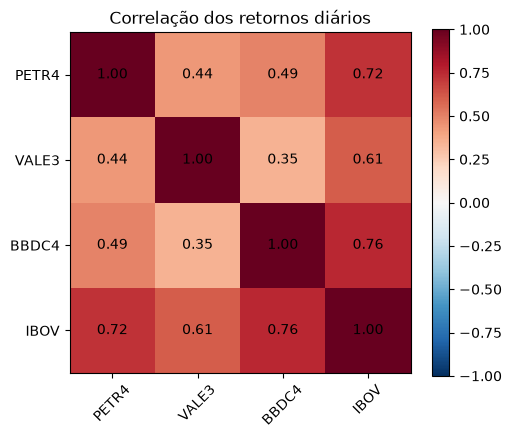

In [5]:
corr = rets[TICKERS + [MARKET]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
labels = [c.replace(".SA", "").replace("^BVSP", "IBOV") for c in corr.columns]
ax.set_xticks(range(len(labels)), labels, rotation=45)
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Correlação dos retornos diários")
ax.grid(False)
fig.colorbar(im)
plt.show()

## 3. Carteira 30/40/30

Pesos fixos: 30% PETR4, 40% VALE3, 30% BBDC4. O retorno esperado é a média ponderada e a variância usa a
matriz de covariância:

$$\sigma_p^2 = w^\top \Sigma\, w$$

In [6]:
weights = np.array([0.30, 0.40, 0.30])
assert np.isclose(weights.sum(), 1.0)

mu = rets[TICKERS].mean() * TRADING_DAYS
cov = rets[TICKERS].cov() * TRADING_DAYS

pf_ret = float(weights @ mu)
pf_var = float(weights @ cov.values @ weights)
pf_vol = pf_var ** 0.5
pf_sharpe = (pf_ret - rf_annual) / pf_vol

print(f"Retorno anual:      {pf_ret:.2%}")
print(f"Variância anual:    {pf_var:.4f}")
print(f"Volatilidade anual: {pf_vol:.2%}")
print(f"Sharpe:             {pf_sharpe:.2f}")

# a volatilidade da carteira deve ser menor que a media ponderada das volatilidades (diversificação)
avg_vol = float(weights @ (rets[TICKERS].std() * np.sqrt(TRADING_DAYS)))
print(f"Média ponderada das volatilidades individuais: {avg_vol:.2%}  ->  ganho de diversificação: {avg_vol - pf_vol:.2%}")
assert pf_vol < avg_vol

Retorno anual:      19.54%
Variância anual:    0.0840
Volatilidade anual: 28.99%
Sharpe:             0.36
Média ponderada das volatilidades individuais: 36.86%  ->  ganho de diversificação: 7.87%


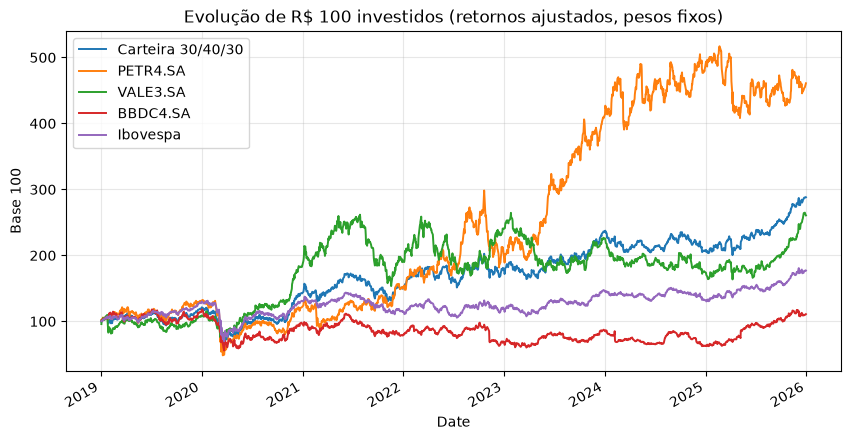

In [7]:
pf_daily = rets[TICKERS] @ weights          # rebalanceada diariamente para os pesos-alvo
growth = (1 + pd.concat([pf_daily.rename("Carteira 30/40/30"), rets[TICKERS], rets[MARKET].rename("Ibovespa")], axis=1)).cumprod() * 100

ax = growth.plot(figsize=(10, 5), lw=1.4)
ax.set_title("Evolução de R$ 100 investidos (retornos ajustados, pesos fixos)")
ax.set_ylabel("Base 100")
plt.show()

## 4. Retorno esperado e variância por cenários (exercício didático)

Quando se trabalha com cenários em vez de uma série histórica, o retorno esperado é a média dos retornos
de cada cenário ponderada pela probabilidade, e a variância mede a dispersão em torno dele:

$$E[R] = \sum_i p_i R_i \qquad \sigma^2 = \sum_i p_i\,(R_i - E[R])^2$$

Exemplo: três cenários (otimista, base e pessimista) com probabilidades 25%, 45% e 30%.

In [8]:
prob = np.array([0.25, 0.45, 0.30])
retorno_cenario = np.array([20.0, 15.0, 5.0])      # em % no período
assert np.isclose(prob.sum(), 1.0)

retorno_esperado = float(prob @ retorno_cenario)
variancia = float(prob @ (retorno_cenario - retorno_esperado) ** 2)
desvio = variancia ** 0.5

print(f"Retorno esperado: {retorno_esperado:.2f}%")
print(f"Variância:        {variancia:.4f} (%²)")
print(f"Desvio-padrão:    {desvio:.2f}%")

assert np.isclose(retorno_esperado, 13.25)
assert np.isclose(variancia, 33.1875)

Retorno esperado: 13.25%
Variância:        33.1875 (%²)
Desvio-padrão:    5.76%


## 5. CAPM: beta, SML e alfa de Jensen

O CAPM diz que o retorno esperado de um ativo depende apenas do seu risco sistemático (**beta**):

$$E[R_i] = r_f + \beta_i\,(E[R_m] - r_f)$$

O beta é estimado por regressão dos **retornos em excesso** do ativo sobre os do mercado (Ibovespa):

$$R_i - r_f = \alpha_i + \beta_i\,(R_m - r_f) + \varepsilon_i$$

O $\alpha_i$ é o **alfa de Jensen**: o retorno que sobrou (ou faltou) em relação ao que o CAPM previa.

In [9]:
ex = rets[TICKERS + [MARKET]].sub(rf_d, axis=0)
ex["Carteira"] = (ex[TICKERS] @ weights)
mkt = sm.add_constant(ex[MARKET])

linhas = {}
for nome in TICKERS + ["Carteira"]:
    res = sm.OLS(ex[nome], mkt).fit()
    linhas[nome.replace(".SA", "")] = {
        "beta": res.params[MARKET],
        "alfa (a.a.)": res.params["const"] * TRADING_DAYS,
        "p-valor do alfa": res.pvalues["const"],
        "R²": res.rsquared,
        "p-valor do beta": res.pvalues[MARKET],
        "erro-padrão do beta": res.bse[MARKET],
    }
capm = pd.DataFrame(linhas).T

# verificacao: por linearidade do OLS, o beta da carteira e a media ponderada dos betas
beta_ponderado = float(weights @ capm.loc[[t.replace(".SA", "") for t in TICKERS], "beta"].values)
assert np.isclose(capm.loc["Carteira", "beta"], beta_ponderado)
print(f"Beta da carteira = {capm.loc['Carteira', 'beta']:.3f} (média ponderada dos betas: {beta_ponderado:.3f})")

capm.style.format({"beta": "{:.3f}", "alfa (a.a.)": "{:.2%}", "p-valor do alfa": "{:.2f}", "R²": "{:.2f}",
                   "p-valor do beta": "{:.1e}", "erro-padrão do beta": "{:.3f}"})

Beta da carteira = 1.077 (média ponderada dos betas: 1.077)


,beta,alfa (a.a.),p-valor do alfa,R²,p-valor do beta,erro-padrão do beta
PETR4,1.236,18.77%,0.07,0.53,1.2e-283,0.028
VALE3,0.928,9.49%,0.38,0.37,9.8e-175,0.029
BBDC4,1.116,-3.79%,0.66,0.57,0.0e+00,0.023
Carteira,1.077,8.29%,0.12,0.76,0.0e+00,0.014


Prêmio de risco do mercado (Ibovespa - Selic): 2.39% a.a.


,beta,Retorno realizado,Retorno CAPM,Alfa de Jensen
PETR4,1.236,30.78%,12.01%,18.77%
VALE3,0.928,20.77%,11.28%,9.49%
BBDC4,1.116,7.94%,11.73%,-3.79%
Carteira,1.077,19.92%,11.63%,8.29%


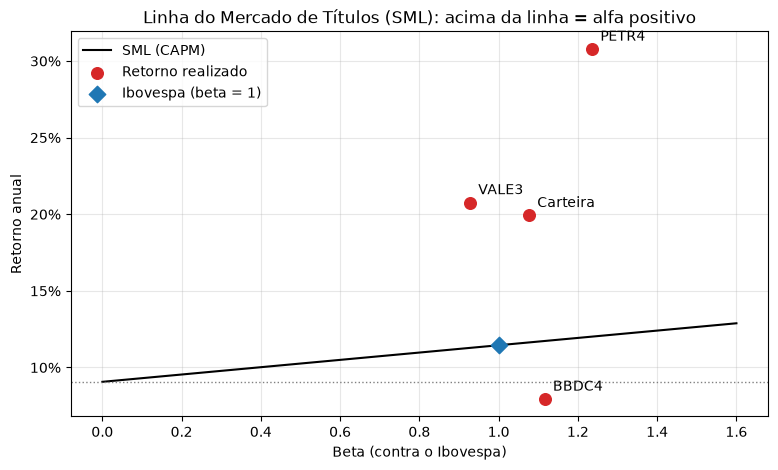

In [10]:
mrp = ex[MARKET].mean() * TRADING_DAYS                 # prêmio de risco do mercado, a.a.
print(f"Prêmio de risco do mercado (Ibovespa - Selic): {mrp:.2%} a.a.")

nomes = [t.replace(".SA", "") for t in TICKERS] + ["Carteira"]
betas = capm.loc[nomes, "beta"].values
realizado = np.array([rf_annual + ex[n if n == "Carteira" else n + ".SA"].mean() * TRADING_DAYS for n in nomes])
capm_esperado = rf_annual + betas * mrp
jensen = realizado - capm_esperado

tabela = pd.DataFrame({"beta": betas, "Retorno realizado": realizado,
                       "Retorno CAPM": capm_esperado, "Alfa de Jensen": jensen}, index=nomes)
display(tabela.style.format({"beta": "{:.3f}", "Retorno realizado": "{:.2%}", "Retorno CAPM": "{:.2%}", "Alfa de Jensen": "{:.2%}"}))

# o alfa de Jensen por esta conta deve coincidir com o intercepto da regressão (anualizado)
assert np.allclose(jensen, capm.loc[nomes, "alfa (a.a.)"].values)

x = np.linspace(0, max(1.6, betas.max() + 0.2), 50)
fig, ax = plt.subplots()
ax.plot(x, rf_annual + x * mrp, color="black", lw=1.5, label="SML (CAPM)")
ax.scatter(betas, realizado, s=70, zorder=3, color="tab:red", label="Retorno realizado")
# o proprio mercado tem beta = 1 e, por construcao, cai sobre a SML (verificacao visual)
ax.scatter([1.0], [rf_annual + mrp], s=70, zorder=3, marker="D", color="tab:blue", label="Ibovespa (beta = 1)")
for n, b, r in zip(nomes, betas, realizado):
    ax.annotate(n, (b, r), textcoords="offset points", xytext=(6, 6))
ax.axhline(rf_annual, color="gray", ls=":", lw=1)
ax.set_xlabel("Beta (contra o Ibovespa)")
ax.set_ylabel("Retorno anual")
ax.set_title("Linha do Mercado de Títulos (SML): acima da linha = alfa positivo")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()
plt.show()

**Leitura.** Ativos acima da SML entregaram retorno superior ao exigido pelo seu risco sistemático (alfa
positivo); abaixo, inferior. **Atenção ao p-valor do alfa** na tabela da regressão: um alfa anualizado
alto pode não ser estatisticamente distinto de zero, porque o retorno diário é muito ruidoso. Já o beta é
estimado com folga (p-valor desprezível). Ressalvas: (i) o alfa estimado vem de uma única amostra; (ii) o Ibovespa é só uma proxy da carteira de mercado; (iii) o CAPM é um modelo
de um fator, e a baixa aderência empírica é bem documentada na literatura.

## 6. Fronteira eficiente (Markowitz)

Para cada nível de retorno-alvo, a carteira **eficiente** é a de menor variância (sem posições vendidas e
com pesos somando 1). Comparamos 20.000 carteiras aleatórias com a fronteira obtida por otimização
(SLSQP) e marcamos a carteira de variância mínima, a de máximo Sharpe e a 30/40/30.

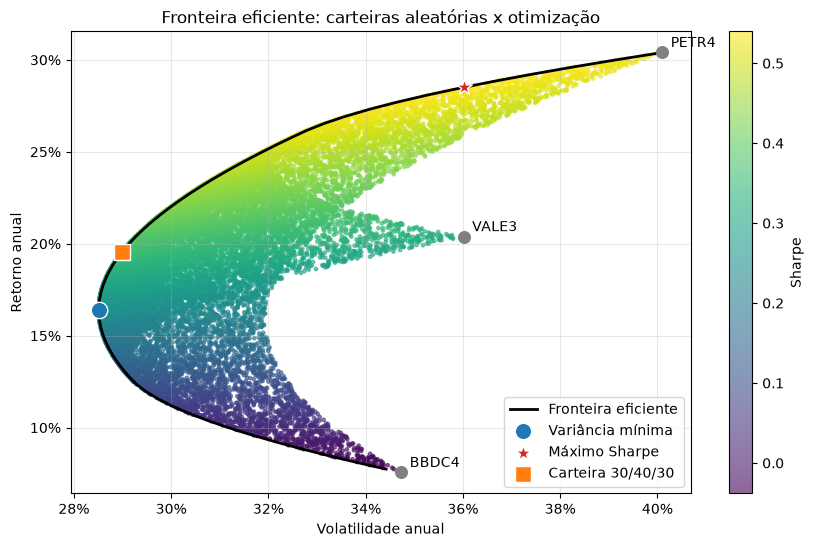

,Variância mínima,Máximo Sharpe,Carteira 30/40/30
PETR4,16.07%,81.17%,30.00%
VALE3,40.29%,18.83%,40.00%
BBDC4,43.64%,0.00%,30.00%
Retorno,16.40%,28.51%,19.54%
Volatilidade,28.51%,36.03%,28.99%
Sharpe,0.26,0.54,0.36


In [11]:
mu_v, cov_m = mu.values, cov.values
n = len(mu_v)
bounds = [(0.0, 1.0)] * n
sum1 = {"type": "eq", "fun": lambda w: w.sum() - 1}


def perf(w):
    r = float(w @ mu_v)
    v = float(np.sqrt(w @ cov_m @ w))
    return r, v, (r - rf_annual) / v


# carteiras aleatorias (Dirichlet = pesos nao-negativos que somam 1)
W = np.random.dirichlet(np.ones(n), size=20_000)
R = W @ mu_v
V = np.sqrt(np.einsum("ij,jk,ik->i", W, cov_m, W))
S = (R - rf_annual) / V

w0 = np.ones(n) / n
w_minvar = minimize(lambda w: w @ cov_m @ w, w0, method="SLSQP", bounds=bounds, constraints=[sum1]).x
w_maxsharpe = minimize(lambda w: -perf(w)[2], w0, method="SLSQP", bounds=bounds, constraints=[sum1]).x

alvos = np.linspace(R.min(), R.max(), 60)
front = []
for alvo in alvos:
    cons = [sum1, {"type": "eq", "fun": lambda w, a=alvo: w @ mu_v - a}]
    r = minimize(lambda w: w @ cov_m @ w, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if r.success:
        front.append((np.sqrt(r.fun), alvo))
front = np.array(front)

# verificacoes de consistencia
for w in (w_minvar, w_maxsharpe):
    assert np.isclose(w.sum(), 1, atol=1e-6) and (w >= -1e-8).all()
assert perf(w_minvar)[1] <= V.min() + 1e-6, "a variância mínima deve ser <= a de qualquer carteira aleatória"
assert perf(w_maxsharpe)[2] >= S.max() - 1e-6, "o Sharpe máximo deve ser >= o de qualquer carteira aleatória"

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(V, R, c=S, cmap="viridis", s=6, alpha=0.6)
ax.plot(front[:, 0], front[:, 1], color="black", lw=2, label="Fronteira eficiente")
for w, nome, cor, mk in [(w_minvar, "Variância mínima", "tab:blue", "o"), (w_maxsharpe, "Máximo Sharpe", "tab:red", "*"),
                         (weights, "Carteira 30/40/30", "tab:orange", "s")]:
    r, v, _ = perf(w)
    ax.scatter(v, r, s=140, color=cor, marker=mk, zorder=4, edgecolor="white", label=nome)
for i, t in enumerate(TICKERS):
    ax.scatter(np.sqrt(cov_m[i, i]), mu_v[i], s=70, color="gray", zorder=3)
    ax.annotate(t.replace(".SA", ""), (np.sqrt(cov_m[i, i]), mu_v[i]), textcoords="offset points", xytext=(6, 4))
fig.colorbar(sc, label="Sharpe")
ax.set_xlabel("Volatilidade anual")
ax.set_ylabel("Retorno anual")
ax.set_title("Fronteira eficiente: carteiras aleatórias x otimização")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="lower right")
plt.show()

resumo = pd.DataFrame(
    {nome: [*w, *perf(w)] for nome, w in [("Variância mínima", w_minvar), ("Máximo Sharpe", w_maxsharpe), ("Carteira 30/40/30", weights)]},
    index=[t.replace(".SA", "") for t in TICKERS] + ["Retorno", "Volatilidade", "Sharpe"],
)
resumo.style.format("{:.2%}", subset=pd.IndexSlice[:"Volatilidade", :]).format("{:.2f}", subset=pd.IndexSlice[["Sharpe"], :])

**Cuidado.** A carteira de máximo Sharpe é muito sensível ao retorno médio histórico, que é estimado com
muito ruído. Os pesos acima descrevem o **passado desta amostra**; usá-los como recomendação seria
sobreajuste. Em prática, usam-se restrições adicionais, *shrinkage* da covariância e validação fora da amostra.

## 7. Black-Scholes: opção europeia

Preço de uma opção europeia sobre ativo sem dividendos, com $d_1 = \dfrac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$
e $d_2 = d_1 - \sigma\sqrt{T}$:

$$C = S\,N(d_1) - K e^{-rT} N(d_2) \qquad P = K e^{-rT} N(-d_2) - S\,N(-d_1)$$

Verificamos a implementação de duas formas: pela **paridade put-call** ($C - P = S - K e^{-rT}$) e por
**simulação de Monte Carlo** do movimento browniano geométrico.

In [12]:
def bs_d1_d2(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)


def bs_price(S, K, T, r, sigma, tipo="call"):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    if tipo == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def bs_delta(S, K, T, r, sigma, tipo="call"):
    d1, _ = bs_d1_d2(S, K, T, r, sigma)
    return norm.cdf(d1) if tipo == "call" else norm.cdf(d1) - 1


# parametros do exemplo: PETR4 no fim da amostra
S0 = float(prices["PETR4.SA"].iloc[-1])
K = round(S0 * 1.05, 2)                                   # strike 5% acima do spot
T = 0.25                                                  # 3 meses
sigma = float(rets["PETR4.SA"].tail(TRADING_DAYS).std() * np.sqrt(TRADING_DAYS))   # vol historica de 1 ano
r_cont = float(np.log(1 + rf_annual))                     # taxa continua equivalente

call = bs_price(S0, K, T, r_cont, sigma, "call")
put = bs_price(S0, K, T, r_cont, sigma, "put")
print(f"S0 = {S0:.2f} | K = {K:.2f} | T = {T} ano | sigma = {sigma:.1%} | r = {r_cont:.2%} (continua)")
print(f"Call: {call:.4f} | Put: {put:.4f} | delta da call: {bs_delta(S0, K, T, r_cont, sigma):.3f}")

# 1) paridade put-call
paridade = (call - put) - (S0 - K * np.exp(-r_cont * T))
print(f"Paridade put-call (deve ser ~0): {paridade:.2e}")
assert abs(paridade) < 1e-9

# 2) Monte Carlo (GBM neutro ao risco)
rng = np.random.default_rng(42)
z = rng.standard_normal(400_000)
ST = S0 * np.exp((r_cont - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
payoff = np.exp(-r_cont * T) * np.maximum(ST - K, 0)
mc, erro = payoff.mean(), payoff.std() / np.sqrt(len(payoff))
print(f"Call por Monte Carlo: {mc:.4f} ± {erro:.4f} (Black-Scholes: {call:.4f})")
assert abs(mc - call) < 4 * erro, "Monte Carlo e Black-Scholes divergem"

S0 = 28.98 | K = 30.43 | T = 0.25 ano | sigma = 22.6% | r = 8.68% (continua)
Call: 0.9652 | Put: 1.7634 | delta da call: 0.427
Paridade put-call (deve ser ~0): 0.00e+00
Call por Monte Carlo: 0.9661 ± 0.0028 (Black-Scholes: 0.9652)


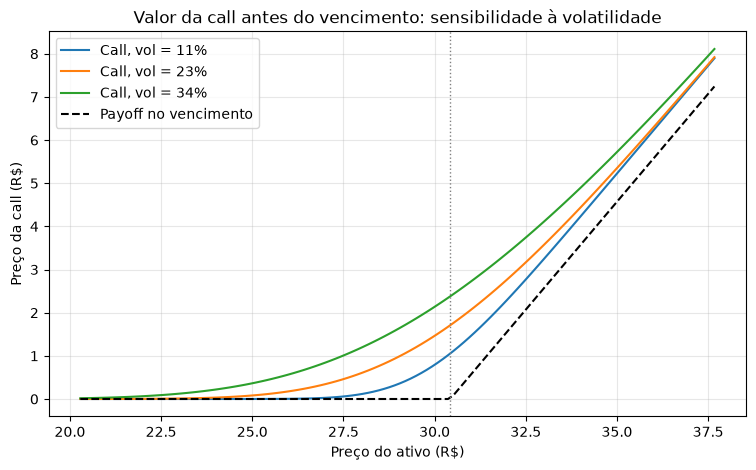

In [13]:
spots = np.linspace(S0 * 0.7, S0 * 1.3, 120)
fig, ax = plt.subplots()
for sg in (0.5 * sigma, sigma, 1.5 * sigma):
    ax.plot(spots, bs_price(spots, K, T, r_cont, sg, "call"), label=f"Call, vol = {sg:.0%}")
ax.plot(spots, np.maximum(spots - K, 0), color="black", ls="--", label="Payoff no vencimento")
ax.axvline(K, color="gray", ls=":", lw=1)
ax.set_xlabel("Preço do ativo (R$)")
ax.set_ylabel("Preço da call (R$)")
ax.set_title("Valor da call antes do vencimento: sensibilidade à volatilidade")
ax.legend()
plt.show()

## Limitações e próximos passos

- **Dentro da amostra.** Betas, alfas e a fronteira foram estimados na mesma janela em que são avaliados.
  Um próximo passo natural é validar fora da amostra (janela móvel) e medir a estabilidade dos betas.
- **Dividendos.** O Black-Scholes aqui ignora dividendos; para ações que pagam proventos relevantes
  (como PETR4 e VALE3), isso tende a superestimar o valor de calls. As convenções das opções listadas
  na B3 também diferem do modelo europeu simplificado.
- **Volatilidade constante.** O modelo supõe volatilidade constante; o mercado precifica um *smile*.
  Próximo passo: volatilidade implícita a partir de preços observados.
- **Um fator.** O CAPM usa só o mercado. Modelos multifatoriais (Fama-French) são a extensão natural.